### CA1 @ EPS Course
#### Instructors: Dr. Bahrak, Dr. Vahabie
##### TAs: Sepanta Ghonoodi, Mohammad Khoshroo
---

*Full Name:* MohammadHossein Kabiri samani

*SID:* 810103496

---

# R tutorial:
You can access a notebook introducing basic R syntax and functions here, if you are interested:

[Comprehensive R Programming Tutorial](https://colab.research.google.com/drive/1xOqhkMF-5DVmjHHdPtjDfi7_CaRvZjDk?usp=sharing)

You can access first computer assignment from one of the previous semesters here:

[CA1](https://colab.research.google.com/drive/13I9i0DwUgy7Nji1Ab6832pdAatXjnLuS?usp=sharing)

# Frequency Definition of Probability


One way of deﬁning the probability of an event is in terms of its relative frequency.

$$P(E) = \lim_{n \to \infty} \frac{n(E)}{n} $$

Where

$E$: an Event from the Sample Space S

$n$: Total number of experiments

$n(E)$: Number of times in the ﬁrst n repetitions of the experiment that the event E occurs


### Defining sample space and probability of each event


In [2]:
S <- seq(1,6)
prob_dice <- rep(1/6, 6)

### Sampling(5 pts)


In [ ]:
roll_dice <- function(n) {
    rolls <- sample(1:6, size = n, replace = TRUE)
  return(rolls)
}

roll_dice(10)

[1] 1 3 1 4 6 3 6 5 6 5

# Problem 1: Galileo's Problem(55 pts)


Suppose three dice are thrown and the three numbers obtained added. The total scores of 9, 10, 11, and 12 can all be obtained in six different combinations. Why then is a total score of 10 or 11 more likely than a total score of 9 or 12?


We now there are 6 ways to get a sum of 9, if you ignore the order of the dice:

- 3 + 3 + 3
- 2 + 3 + 4
- 2 + 2 + 5
- 1 + 4 + 4
- 1 + 3 + 5
- 1 + 2 + 6

and 6 ways to get a sum of 10:

- 3 + 3 + 4
- 2 + 4 + 4
- 2 + 3 + 5
- 2 + 2 + 6
- 1 + 4 + 5
- 1 + 3 + 6

So Based on classical definition of probability shouldn't they be equally likely?

let's figure out with sampling!


###  Simulating rolling n dices k times(5 pts)

Use `replicate()` function to simulate rolling 3 dices at a time


In [ ]:
sum_of_n_dices <- function(n, k) {
  results <- replicate(k, sum(sample(1:6, n, replace = TRUE)))
  return(results)
}

sum_of_n_dices(3, 10)


[1] 10 14 13 14  8 13  6  7  8  7

### Generate and Store Samples(10 pts)

Now repeat the experiment with 3 dices $10^k$ times, for k ranging from 2 to 6.

For each k:

- Count how many times we have a sum of 9, 10, 11, 12.
- Calculate the probability using frequency definition
- Store these probabilities in a data frame

You can use `table()` and `factor()` function to count the results if necessary.


In [7]:

sum_of_n_dices <- function(n, k) {
  replicate(k, sum(sample(1:6, n, replace = TRUE)))
}
sample_sizes <- 10^(2:6)
target_sums <- c(9, 10, 11, 12)
prob_df <- data.frame(
  SampleSize = sample_sizes,
  P_9 = NA,
  P_10 = NA,
  P_11 = NA,
  P_12 = NA
)
for (i in 1:length(sample_sizes)) {
  size <- sample_sizes[i]
  rolls <- sum_of_n_dices(3, size)
  counts <- table(factor(rolls, levels = target_sums))
  probs <- counts / size
  prob_df[i, 2:5] <- probs
}
print(prob_df)


  SampleSize      P_9     P_10    P_11     P_12
1      1e+02 0.110000 0.160000 0.14000 0.140000
2      1e+03 0.109000 0.118000 0.12600 0.113000
3      1e+04 0.115100 0.125300 0.13030 0.116600
4      1e+05 0.114000 0.126100 0.12707 0.115910
5      1e+06 0.115761 0.124778 0.12484 0.115567


### Visualize Probabilities(15 pts)


Plot the probabilities of the sums (9, 10, 11, 12) for 3 dices in a bar plot by completing the function.


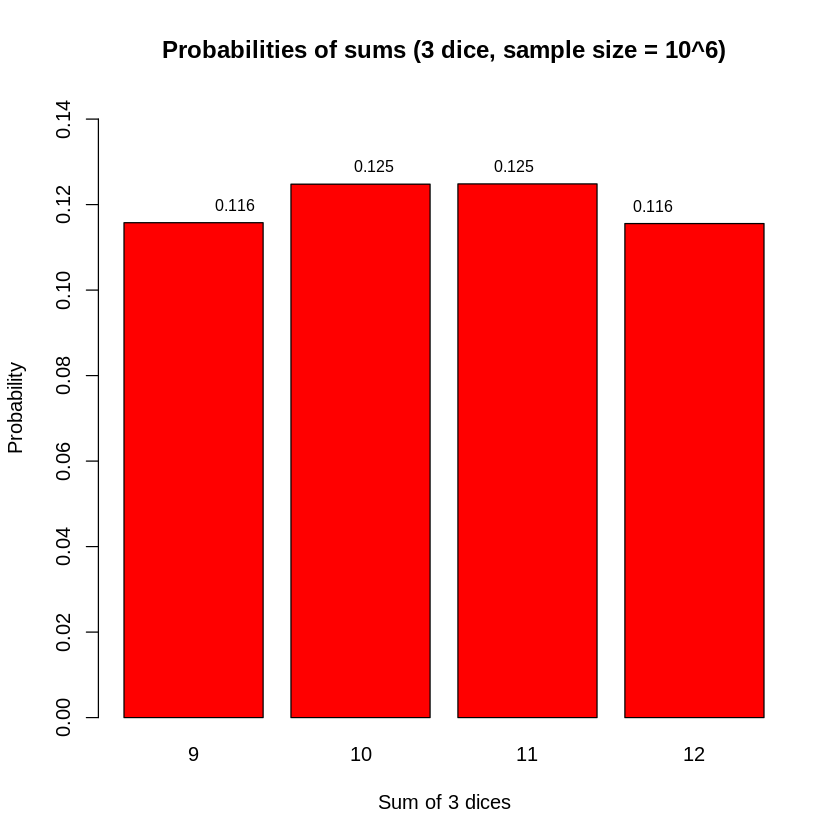

In [10]:

plot_probabilities <- function(names, probs) {

  barplot(
    probs,
    names.arg = names,
    col = "red",
    main = "Probabilities of sums (3 dice, sample size = 10^6)",
    xlab = "Sum of 3 dices",
    ylab = "Probability",
    ylim = c(0, max(probs) + 0.02)
  )

  text(
    x = seq_along(probs),
    y = probs,
    labels = round(probs, 3),
    pos = 3,
    cex = 0.8,
    col = "black"
  )
}


idx <- which(prob_df$SampleSize == 10^6)
probs_for_plot <- as.numeric(prob_df[idx, 2:5])
names_for_plot <- c("9", "10", "11", "12")
plot_probabilities(names_for_plot, probs_for_plot)


- What do you see? Was ignoring count of permutations in the beginning correct or there is problem with the experiment?

    Answer:
The simulation results match the expected probabilities, so the experiment is correct. However, ignoring permutations at the beginning was wrong because different sums have different numbers of combinations (e.g., sum = 10 can occur in more ways than sum = 3). Permutations must be considered.

- Why doesn't classical definition of probability doesn't apply here?

    Answer:

  The classical definition of probability doesn’t apply directly because the sums are not equally likely. Some sums can be obtained through more dice combinations than others, so their probabilities are not uniform.

### Showing the correct value(15 pts)


Calculate the exact probability of the sum of three dice being 9 and 10 (you don’t need to show the detailed calculations in the notebook).

Use a line plot to demonstrate that, as the number of experiments increases, the relative frequencies converge to the calculated probabilities.

Add a horizontal line to indicate the calculated probability in the plot.

Use a logarithmic scale for the sample sizes on the chart.

In [11]:
p_9_exact <- 25/216
p_10_exact <- 27/216
sample_sizes <- c(seq(100,1000,200),
                  seq(1000,10000,2000),
                  seq(10000,100000,20000),
                  seq(100000,1000000,200000))
estimate_probs <- function(n) {
  rolls <- replicate(n, sum(sample(1:6, 3, replace = TRUE)))
  p9 <- sum(rolls == 9) / n
  p10 <- sum(rolls == 10) / n
  return(c(p9, p10))
}
probabilities <- t(sapply(sample_sizes, estimate_probs))
prob_df <- data.frame(
  SampleSize = sample_sizes,
  P9 = probabilities[,1],
  P10 = probabilities[,2]
)

print(prob_df)


   SampleSize         P9       P10
1       1e+02 0.15000000 0.1400000
2       3e+02 0.09666667 0.1400000
3       5e+02 0.12000000 0.1220000
4       7e+02 0.09714286 0.1171429
5       9e+02 0.11555556 0.1300000
6       1e+03 0.10500000 0.1280000
7       3e+03 0.10966667 0.1243333
8       5e+03 0.11460000 0.1310000
9       7e+03 0.11500000 0.1200000
10      9e+03 0.11700000 0.1215556
11      1e+04 0.11550000 0.1243000
12      3e+04 0.12006667 0.1258333
13      5e+04 0.11582000 0.1253200
14      7e+04 0.11614286 0.1271429
15      9e+04 0.11556667 0.1253667
16      1e+05 0.11729000 0.1256500
17      3e+05 0.11472667 0.1242467
18      5e+05 0.11659200 0.1250220
19      7e+05 0.11607857 0.1254929
20      9e+05 0.11548444 0.1249500


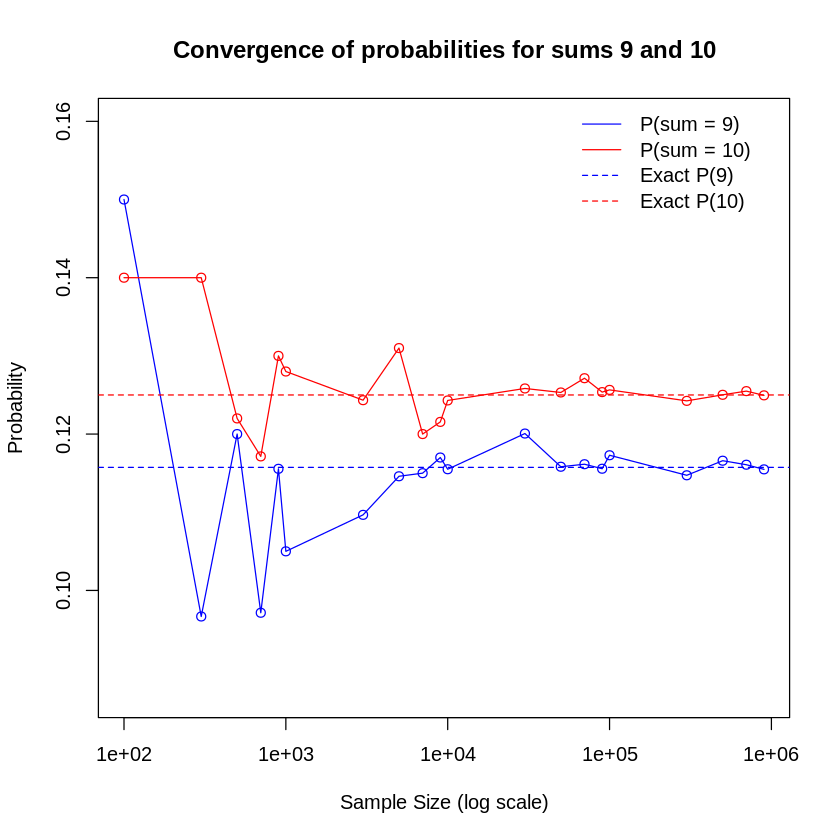

In [12]:
plot(prob_df$SampleSize, prob_df$P9, type = "o", col = "blue",
     log = "x",
     ylim = c(min(prob_df$P9, prob_df$P10) - 0.01,
              max(prob_df$P9, prob_df$P10) + 0.01),
     xlab = "Sample Size (log scale)",
     ylab = "Probability",
     main = "Convergence of probabilities for sums 9 and 10")


lines(prob_df$SampleSize, prob_df$P10, type = "o", col = "red")


abline(h = p_9_exact, col = "blue", lty = 2)
abline(h = p_10_exact, col = "red", lty = 2)


legend("topright",
       legend = c("P(sum = 9)", "P(sum = 10)",
                  "Exact P(9)", "Exact P(10)"),
       col = c("blue", "red", "blue", "red"),
       lty = c(1, 1, 2, 2),
       bty = "n")


### Increasing Number of Dices(10 pts)
Here, we analyze the distribution of dice sums and observe how it evolves with an increasing number of dice.

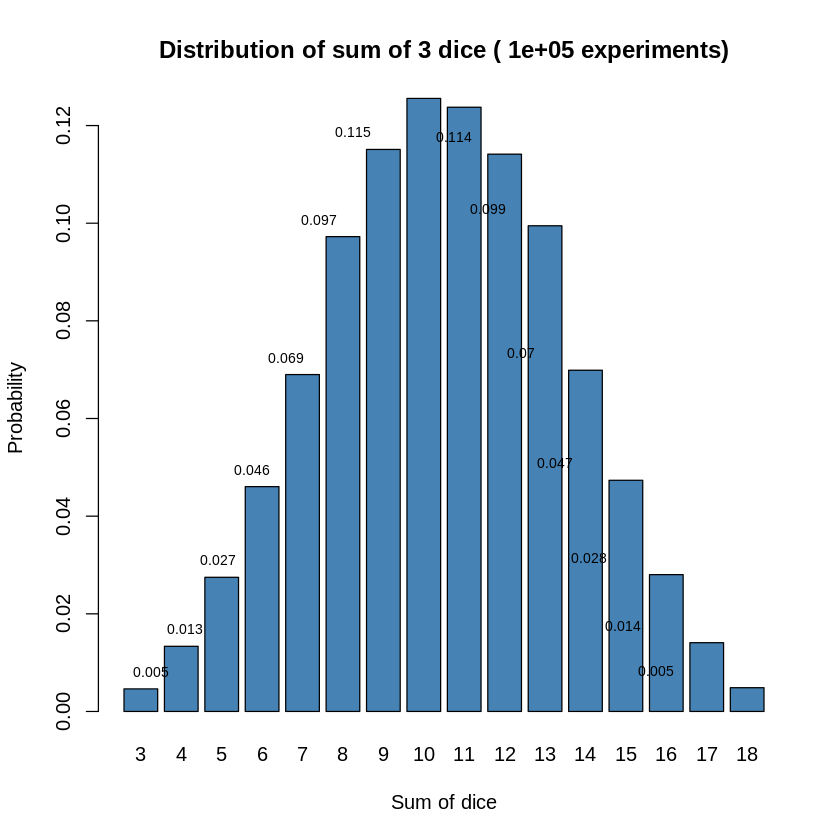

In [13]:
plot_distribution_of_sum_of_n_dices <- function(n, k) {
  sums <- replicate(k, sum(sample(1:6, n, replace = TRUE)))
  counts <- table(sums)
  probs <- counts / k
  barplot(
    probs,
    names.arg = names(probs),
    col = "steelblue",
    main = paste("Distribution of sum of", n, "dice (", k, "experiments)", sep = " "),
    xlab = "Sum of dice",
    ylab = "Probability"
  )
  text(
    x = seq_along(probs),
    y = probs,
    labels = round(probs, 3),
    pos = 3,
    cex = 0.7
  )
}
plot_distribution_of_sum_of_n_dices(3, 100000)


Call `plot_distribution_of_sum_of_n_dices` with different dice counts and 10⁵ experiments.

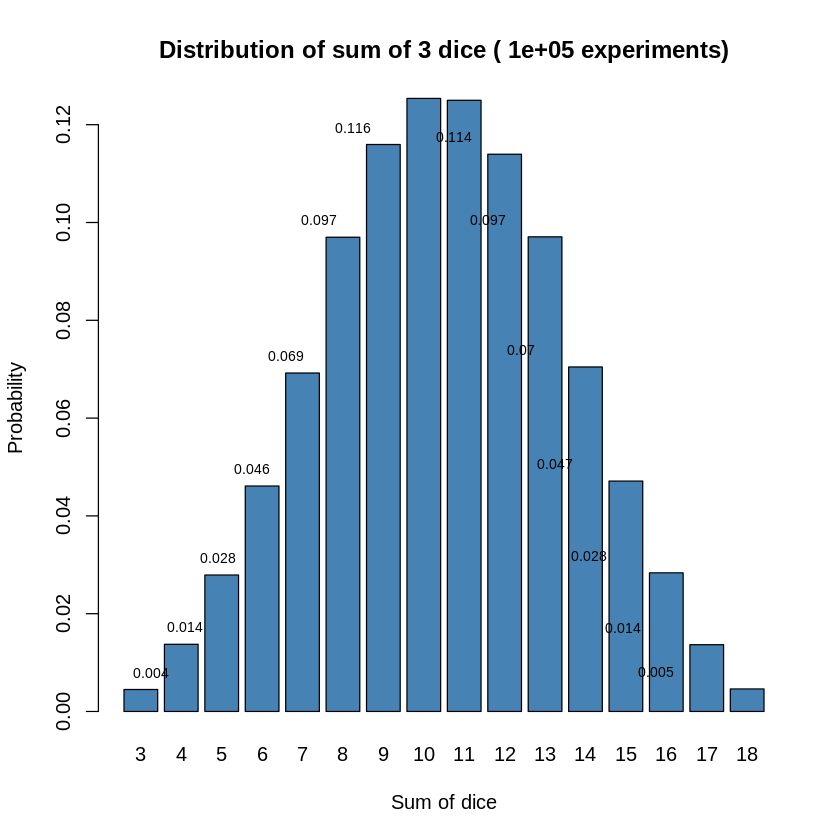

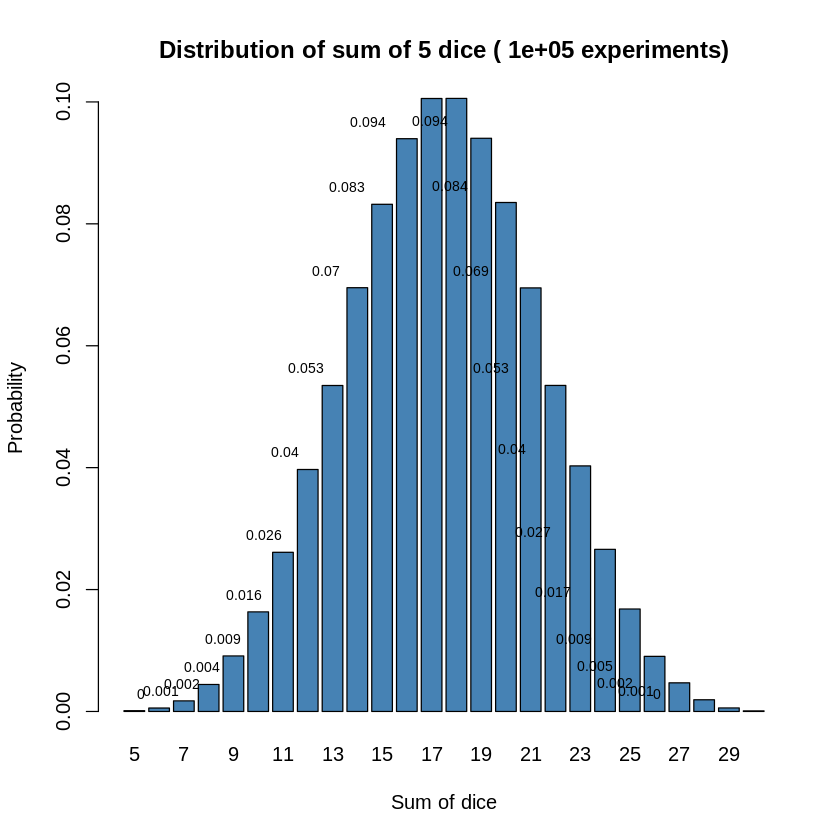

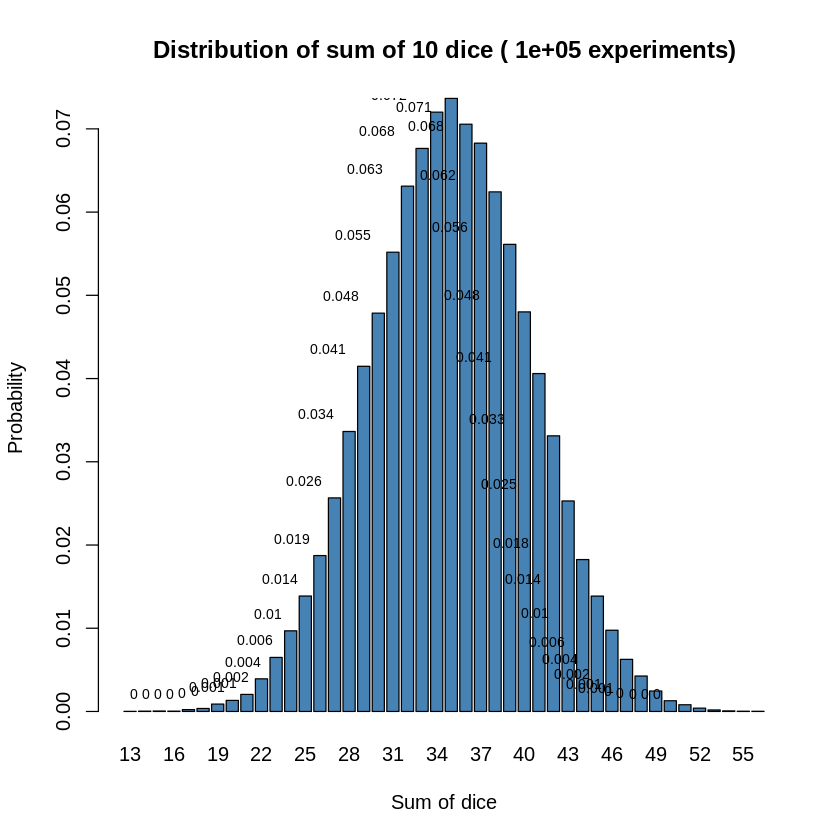

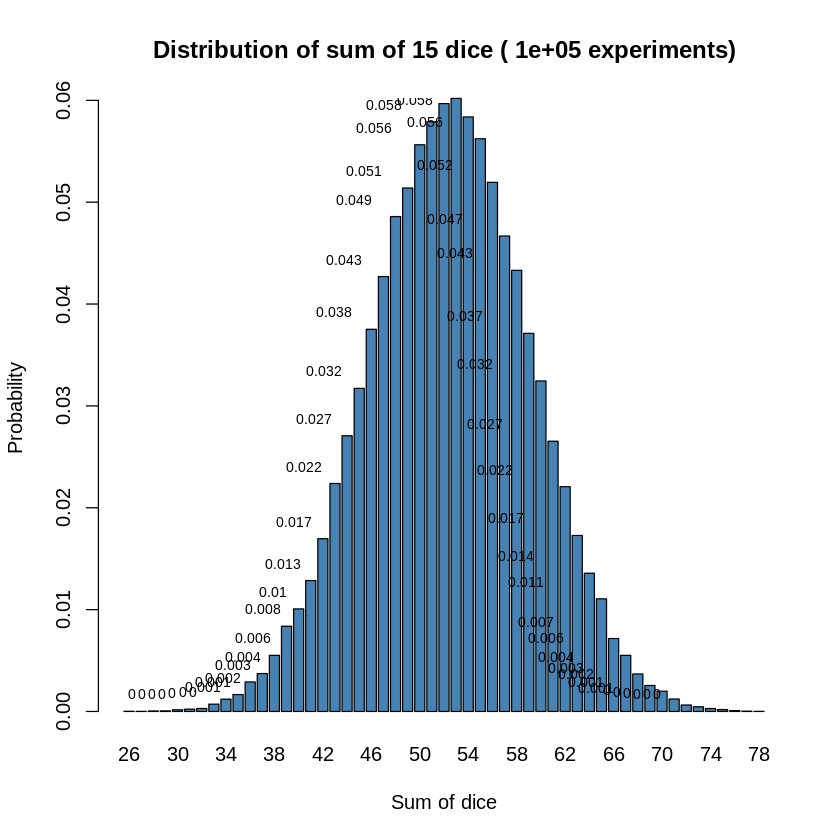

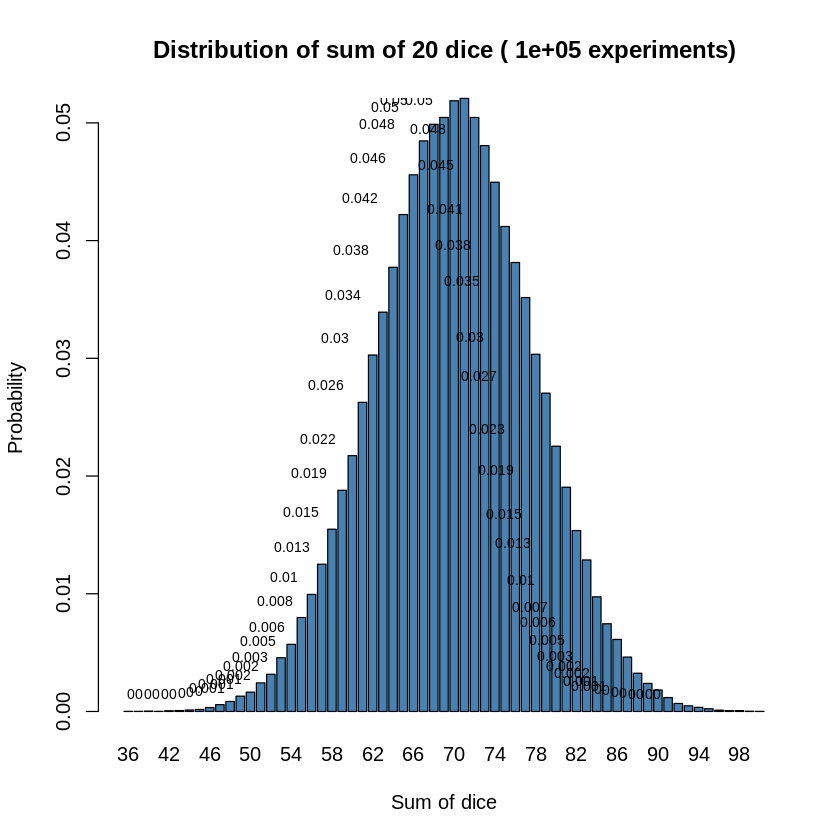

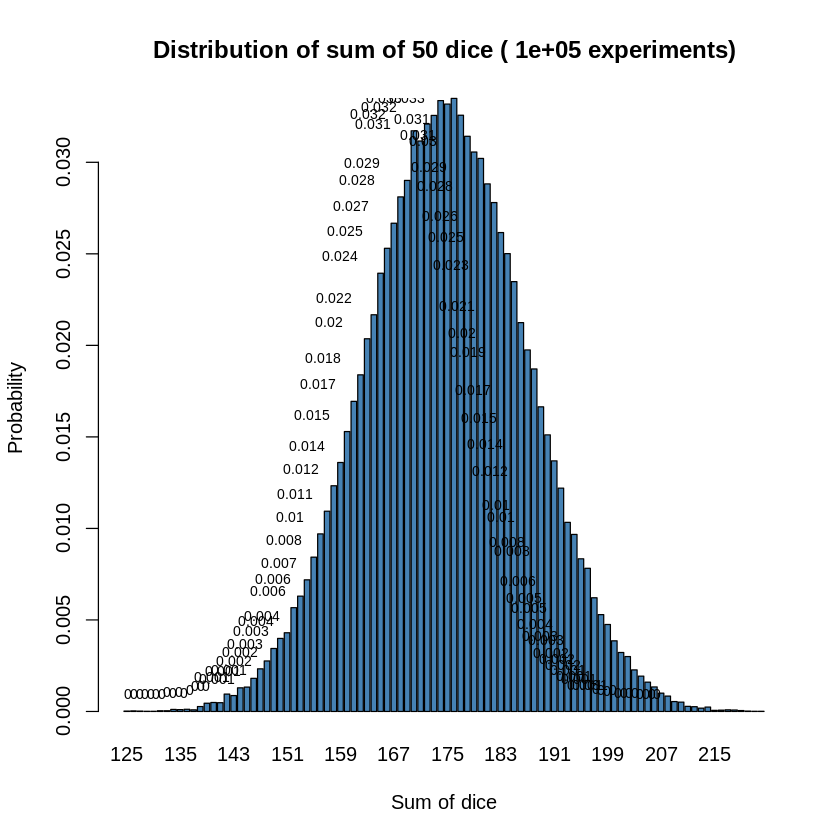

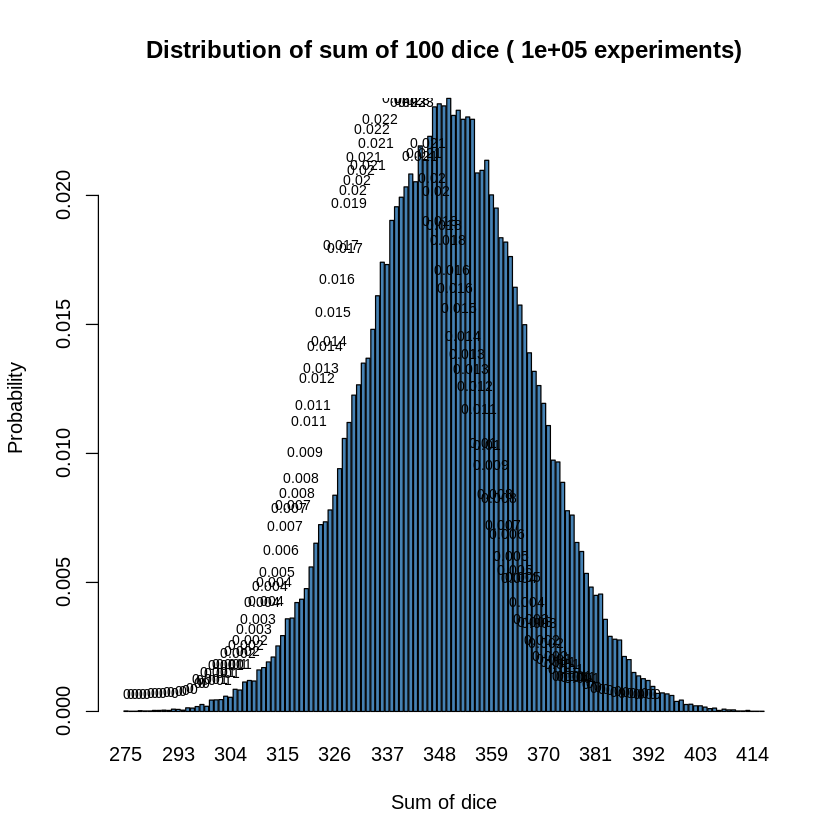

In [14]:
dice_counts <- c(3, 5, 10, 15, 20, 50, 100)

for (n in dice_counts) {
  plot_distribution_of_sum_of_n_dices(n, 10^5)
}



# Problem 2: New class order(40 pts)


In this question you will see that some probability problems are very hard to solve by theory, but become much easier if you use sampling and the frequentist interpretation of probability.


In a university classroom, n students are sitting in a row. After the class ends, they all go outside for a break. When they return, they decide to sit again on the same row, but this time they each choose a seat at random, resulting in a uniform random permutation of the seating order.

Since every pair of neighbors had an argument during the first class and now hate each other, the students want to know:

What is the probability that, in the new seating, There exists two students that sit next to someone they were seated next to in the original arrangement?


### Step 1: Simulate a random sitting order(5 pts)


In [19]:
random_sitting_order <- function(n) {
    sample(1:n, n, replace = FALSE)
}
set.seed(123)
random_sitting_order(15)


[1] 15  3 14 10  2  6  5  4 12  7  1 11 13  8  9

### Step 2: create a new permutation and find if there are similar neighbors(10 pts)


Suppose students are initially seated in order from 1 to n. In the next arrangement, they are placed in a new random order. Determine whether any two neighbors from the original order remain neighbors in the new order.

In [116]:
has_similar_neighbors <- function(students_count) {
  original <- 1:students_count
  new_order <- sample(1:students_count, students_count, replace = FALSE)

  for (i in 1:(students_count - 1)) {
    a <- new_order[i]
    b <- new_order[i + 1]
    if (abs(a - b) == 1) {
      return(TRUE)
    }
  }
  return(FALSE)
}
has_similar_neighbors(10)



[1] TRUE

### Step3: Conduct the experiment N times(5 pts)


Here you should:
- Conduct the experiment N times.
- See how many times there are similar neighbors
- Calculate probability using frequency definition and return it.

In [118]:
similar_neighbors_probability <- function(N, students_count) {
  success_count <- 0
  for (i in 1:N) {
    if (has_similar_neighbors(students_count)) {
      success_count <- success_count + 1
    }
  }
  prob <- success_count / N
  return(prob)
}
set.seed(123)
similar_neighbors_probability(N = 10000, students_count = 10)


[1] 0.8677

### Step 4:(10 pts)
Conduct the experiment for these sample sizes with 5 students.

Print the probabilities for each sample size.

In [119]:

students_count <- 5

sample_sizes <- c(seq(100, 1000, 200),
                  seq(1000, 10000, 2000),
                  seq(10000, 100000, 20000),
                  seq(100000, 1000000, 200000))

probabilities <- numeric(length(sample_sizes))

set.seed(123)
for (i in 1:length(sample_sizes)) {
  N <- sample_sizes[i]
  probabilities[i] <- similar_neighbors_probability(N, students_count)
}
results <- data.frame(
  SampleSize = sample_sizes,
  Probability = probabilities
)
print(results)



   SampleSize Probability
1       1e+02   0.9200000
2       3e+02   0.8733333
3       5e+02   0.8700000
4       7e+02   0.8871429
5       9e+02   0.8866667
6       1e+03   0.8750000
7       3e+03   0.8846667
8       5e+03   0.8796000
9       7e+03   0.8838571
10      9e+03   0.8835556
11      1e+04   0.8848000
12      3e+04   0.8854667
13      5e+04   0.8824600
14      7e+04   0.8831143
15      9e+04   0.8838667
16      1e+05   0.8828000
17      3e+05   0.8829200
18      5e+05   0.8830120
19      7e+05   0.8835086
20      9e+05   0.8833233


Show the probabilities in the You calculated in a line chart.

Use log scale for sample sizes.

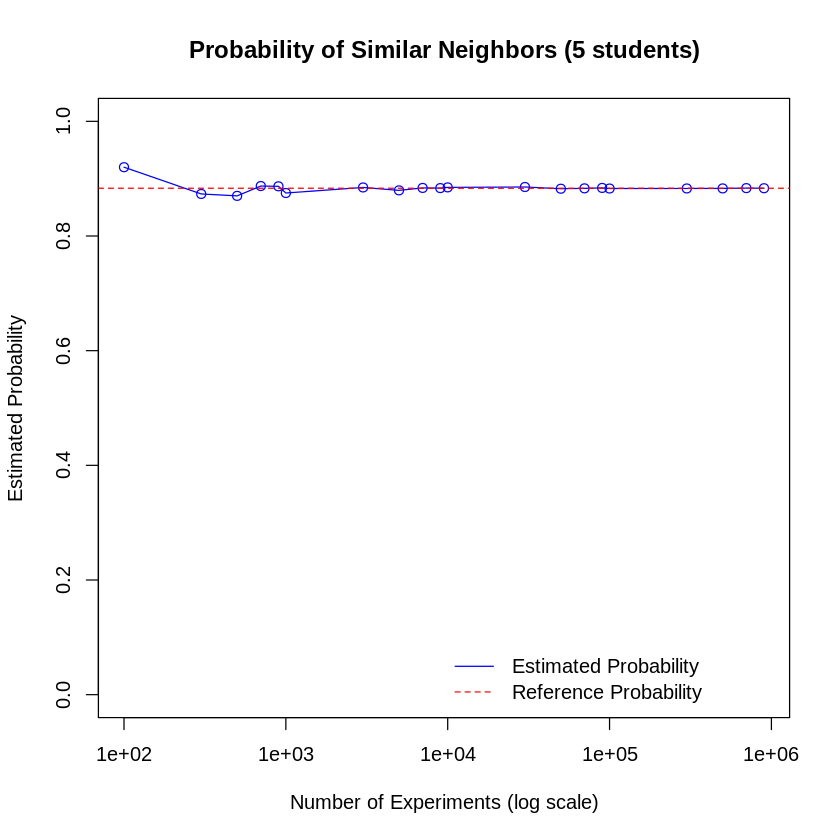

In [120]:

plot(results$SampleSize, results$Probability, type = "o", col = "blue",
     log = "x",
     xlab = "Number of Experiments (log scale)",
     ylab = "Estimated Probability",
     main = "Probability of Similar Neighbors (5 students)",
     ylim = c(0, 1))

abline(h = tail(results$Probability, 1), col = "red", lty = 2)

legend("bottomright",
       legend = c("Estimated Probability", "Reference Probability"),
       col = c("blue", "red"),
       lty = c(1, 2),
       bty = "n")



### Step 5:(10 pts)
In this step, we want to examine the effect of increasing the number of students on the probability.

Calculate the probability that two students sit next to each other again, using a sample size of $10^6$, for 3 to 20 students.

Display the results in a line chart.

   Students Probability
1         3    1.000000
2         4    0.917327
3         5    0.883232
4         6    0.875117
5         7    0.871760
6         8    0.870107
7         9    0.868594
8        10    0.867848
9        11    0.866527
10       12    0.867168
11       13    0.866001
12       14    0.866278
13       15    0.866185
14       16    0.866238
15       17    0.865879
16       18    0.865814
17       19    0.865761
18       20    0.865512


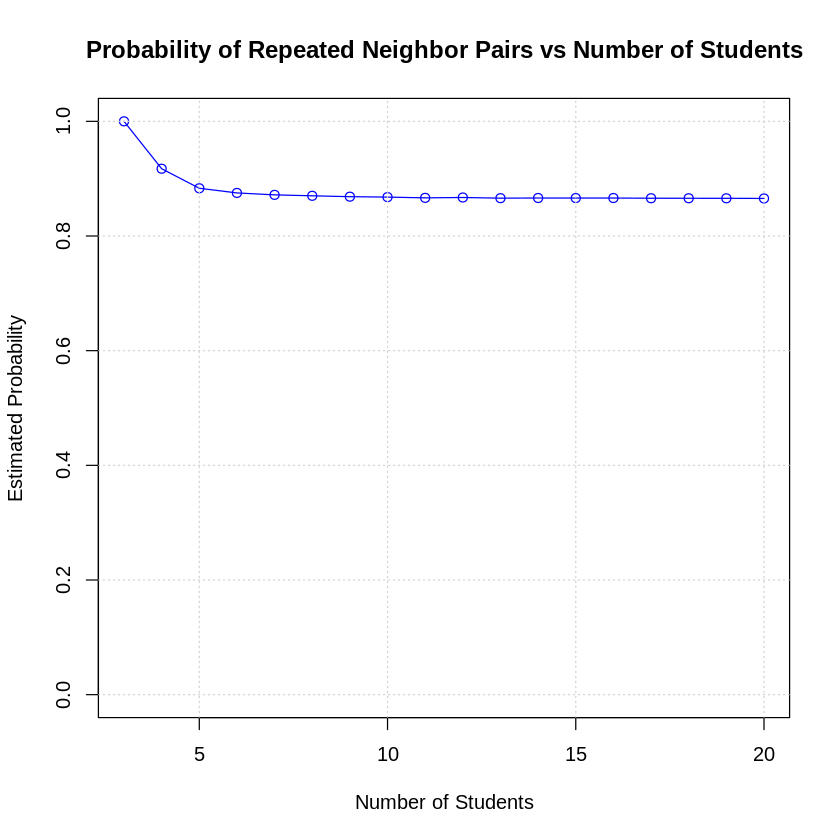

In [121]:

N <- 10^6
student_counts <- 3:20
probabilities <- numeric(length(student_counts))
set.seed(123)
for (i in seq_along(student_counts)) {
  n <- student_counts[i]
  probabilities[i] <- similar_neighbors_probability(N, n)
}

results_students <- data.frame(
  Students = student_counts,
  Probability = probabilities
)

print(results_students)
plot(results_students$Students, results_students$Probability, type = "o", col = "blue",
     xlab = "Number of Students",
     ylab = "Estimated Probability",
     main = "Probability of Repeated Neighbor Pairs vs Number of Students",
     ylim = c(0, 1))

grid()



Now you can see the theoretical way to solve this question using inclusion-exclusion principle.
(Reading part is optional and This part is meant to show you that in some problems sampling is much easier.)

We assume that the initial order of seating is $A, B, C, D$.

We define a function $T(XY)$ that indicates the number of arrangements in which $X$ and $Y$ are seated next to each other.

We know that the total number of arrangements is $5!$. Now, we can determine the number of undesirable cases using Inclusion-Exclusion principle.
$$
\big(|T(AB)| + |T(BC)| + |T(CD)| + |T(DE)|\big)
- \big(|T(AB) \cap T(BC)| + |T(AB) \cap T(CD)| + |T(AB) \cap T(DE)| + \cdots \big) + \cdots
$$

In the above expression, each sentence cannot be calculated separately.
$$|T(AB)| = |T(BC)| = |T(CD)| = |T(DE)| = 2 \times 4! = 48$$


In the case of invalid sequences, we have 4 sequences in the form
$(|T(XY)|)$.

Therefore, in total we will have:
$ 48 \times 4 = 192 $ undesirable elements.

$$|T(AB) \cap T(BC)| = |T(BC) \cap T(CD)| = |T(CD) \cap T(DE)| = 2 \times 3! = 12$$

The expression $T(BC) \cap T(AB)$ represents the set of sequences in which $A$ and $B$ are adjacent, and $B$ and $C$ are also adjacent.
In the case of invalid sequences, we have 3 sequences in this form; thus, in total we will have:  $12 \times 3 = 36 $

$$|T(AB) \cap T(CD)| = |T(AB) \cap T(DE)| = |T(BC) \cap T(DE)| = 2^2 \times 3! = 24$$

The expression $T(AB) \cap T(CD)$ represents the set of sequences in which $A$ and $B$ are adjacent, and $C$ and $D$ are also adjacent.
In the case of invalid sequences, we have 3 sequences in this form; thus, in total we will have:  $24 \times 3 = 72 $

$$|T(AB) \cap T(BC) \cap T(CD)| =$$
$$|T(BC) \cap T(CD) \cap T(DE)| = 2 \times 2! = 4$$


The expression $T(AB) \cap T(BC) \cap T(CD)$ represents the set of sequences in which $A$, $B$, $C$ and $D$ are adjacent.
In the case of invalid sequences, we have 2 sequences in this form; thus, in total we will have:  $2 \times 4 = 8 $

$$|T(AB) \cap T(BC) \cap T(DE)| =$$
$$|T(AB) \cap T(CD) \cap T(DE)| = 2^2 \times 2! = 8$$


The expression $T(AB) \cap T(BC) \cap T(DE)$ represents the set of sequences in which $A$, $B$ and $C$  are adjacent, and $D$ and $E$ are also adjacent.
In the case of invalid sequences, we have 2 sequences in this form; thus, in total we will have:  $2 \times 8 = 16 $


$$|T(AB) \cap T(BC) \cap T(CD) \cap T(DE)| = $$ $$2 \times 1! = 2$$

The expression $T(AB) \cap T(BC) \cap T(CD) \cap T(DE)$ represents a set of arrangements
in which each individual is next to individuals who were next to them in previous arrangements.
This set has only two members.

Therefore all invalid sequences will be:
$$192-(36+72)+(8+16)-2 = 106$$

And valid sequences will be:

$$5!-106 = 14 $$
And the desired probability(probability of each person sitting next to a new person):
$$\frac{14}{5!} = 0.116667$$
The probability that there exists a pair sitting next to each other again is:
$$ 1- \frac{14}{5!} = 0.8833 $$
Does this match with your observation?
